# Setup
Project paths and constants.


In [26]:
import json
import os

import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2, mobilenet_v2

PROJECT_ROOT = r"C:\Users\banya\crop-disease-detection-deep-learning"
DATA_DIR = os.path.join(PROJECT_ROOT, "data", "new_plant_diseases_dataset")
TRAIN_DIR = os.path.join(DATA_DIR, "train")
VALID_DIR = os.path.join(DATA_DIR, "valid")
MODELS_DIR = os.path.join(PROJECT_ROOT, "models")
RESULTS_DIR = os.path.join(PROJECT_ROOT, "results")
FIGURES_DIR = os.path.join(RESULTS_DIR, "figures")
MODEL_PATH = os.path.join(MODELS_DIR, "crop_disease_mobilenetv2_1.keras")
METRICS_PATH = os.path.join(RESULTS_DIR, "mobilenetv2_metrics.json")
ACCURACY_FIG_PATH = os.path.join(FIGURES_DIR, "mobilenetv2_accuracy_curve.png")
LOSS_FIG_PATH = os.path.join(FIGURES_DIR, "mobilenetv2_loss_curve.png")

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 30

os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

keras.utils.set_random_seed(SEED)
tf.random.set_seed(SEED)


# Load Dataset
Load train and validation splits.


In [27]:
raw_train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED,
)

raw_valid_ds = tf.keras.utils.image_dataset_from_directory(
    VALID_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

class_names = raw_train_ds.class_names
num_classes = len(class_names)
AUTOTUNE = tf.data.AUTOTUNE


def prepare_mobilenet_ds(dataset, training=False):
    dataset = dataset.map(
        lambda images, labels: (mobilenet_v2.preprocess_input(tf.cast(images, tf.float32)), labels),
        num_parallel_calls=AUTOTUNE,
    )
    if training:
        dataset = dataset.shuffle(1000, seed=SEED)
    return dataset.prefetch(AUTOTUNE)


train_ds = prepare_mobilenet_ds(raw_train_ds, training=True)
valid_ds = prepare_mobilenet_ds(raw_valid_ds)

print(f"Classes: {num_classes}")
print(f"Train batches: {tf.data.experimental.cardinality(train_ds).numpy()}")
print(f"Valid batches: {tf.data.experimental.cardinality(valid_ds).numpy()}")


Found 70295 files belonging to 38 classes.
Found 17572 files belonging to 38 classes.
Classes: 38
Train batches: 2197
Valid batches: 550


# Build MobileNetV2 Model
Freeze the ImageNet base and add a small classifier head.


In [28]:
base_model = MobileNetV2(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights="imagenet",
)
base_model.trainable = False

mobilenet_model = keras.Sequential(
    [
        layers.Input(shape=IMG_SIZE + (3,)),
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation="softmax"),
    ],
    name="mobilenetv2_classifier",
)

mobilenet_model.compile(
    optimizer=keras.optimizers.Adam(),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

mobilenet_model.summary()


Model: "mobilenetv2_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 38)             │        48,678 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,306,662 (8.80 MB)

 Trainable params: 48,678 (190.15 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

# Training


In [8]:
RUN_TRAINING = True
EPOCHS = 10

if RUN_TRAINING:
    history = mobilenet_model.fit(
        train_ds,
        validation_data=valid_ds,
        epochs=EPOCHS,
        verbose=1,
    )
    mobilenet_model.save(MODEL_PATH)
    print(f"Saved model to {MODEL_PATH}")
else:
    print("Training skipped.")


Epoch 1/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 796s 350ms/step - accuracy: 0.8749 - loss: 0.4361 - val_accuracy: 0.9456 - val_loss: 0.1871
Epoch 2/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 467s 204ms/step - accuracy: 0.9341 - loss: 0.2002 - val_accuracy: 0.9508 - val_loss: 0.1560
Epoch 3/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 420s 187ms/step - accuracy: 0.9434 - loss: 0.1724 - val_accuracy: 0.9548 - val_loss: 0.1391
Epoch 4/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 431s 192ms/step - accuracy: 0.9470 - loss: 0.1564 - val_accuracy: 0.9594 - val_loss: 0.1265
Epoch 5/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 428s 191ms/step - accuracy: 0.9506 - loss: 0.1472 - val_accuracy: 0.9580 - val_loss: 0.1276
Epoch 6/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 419s 187ms/step - accuracy: 0.9507 - loss: 0.1419 - val_accuracy: 0.9594 - val_loss: 0.1240
Epoch 7/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 408s 183ms/step - accuracy: 0.9540 - loss: 0.1371 - val_accuracy: 0.9601 - val_loss: 0.1217
Epoch 8/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 434s 195ms/step - ac

# Load Saved Model
Use the saved `.keras` model for evaluation.


In [30]:
if not os.path.exists(MODEL_PATH):
    raise FileNotFoundError(MODEL_PATH)

mobilenet_model = keras.models.load_model(MODEL_PATH)
print(f"Loaded model from {MODEL_PATH}")


Loaded model from C:\Users\banya\crop-disease-detection-deep-learning\models\crop_disease_mobilenetv2_1.keras


# Evaluate
Evaluate on `valid/`.


In [31]:
mobilenet_val_loss, mobilenet_val_accuracy = mobilenet_model.evaluate(valid_ds, verbose=1)

print(f"Validation accuracy: {mobilenet_val_accuracy:.6f}")
print(f"Validation loss: {mobilenet_val_loss:.6f}")


550/550 ━━━━━━━━━━━━━━━━━━━━ 88s 158ms/step - accuracy: 0.9597 - loss: 0.1234
Validation accuracy: 0.959652
Validation loss: 0.123442


# Accuracy/Loss Graph
Plot accuracy and loss


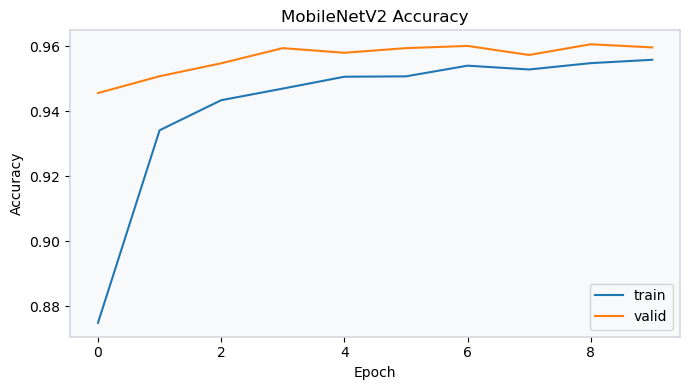

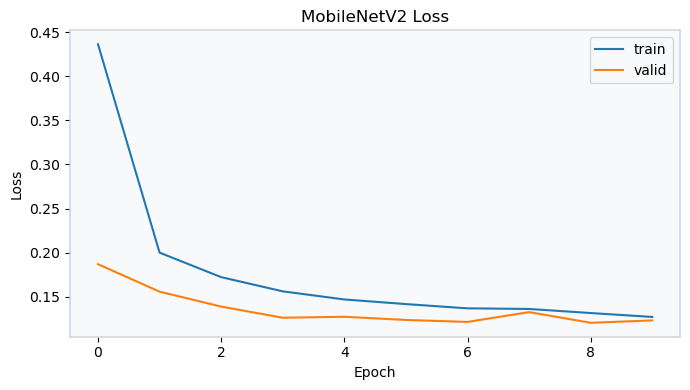

In [23]:
if "history" in globals():
    history_data = history.history

    plt.figure(figsize=(7, 4))
    plt.plot(history_data["accuracy"], label="train")
    plt.plot(history_data["val_accuracy"], label="valid")
    plt.title("MobileNetV2 Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.tight_layout()
    plt.savefig(ACCURACY_FIG_PATH, dpi=200)
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.plot(history_data["loss"], label="train")
    plt.plot(history_data["val_loss"], label="valid")
    plt.title("MobileNetV2 Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.tight_layout()
    plt.savefig(LOSS_FIG_PATH, dpi=200)
    plt.show()
else:
    print("there is no training")


# Save Metrics
Write validation metrics to JSON.


In [24]:
mobilenet_metrics = {
    "model": "MobileNetV2",
    "validation_accuracy": float(mobilenet_val_accuracy),
    "validation_loss": float(mobilenet_val_loss),
    "model_path": MODEL_PATH,
    "evaluation_split": VALID_DIR,
}

with open(METRICS_PATH, "w", encoding="utf-8") as f:
    json.dump(mobilenet_metrics, f, indent=2)

print(f"Saved metrics to {METRICS_PATH}")


Saved metrics to C:\Users\banya\crop-disease-detection-deep-learning\results\mobilenetv2_metrics.json
